# In-class Assignment 6.2

**Week 6 Wednesday**

#### &#x2705; Dengqian (Ken) Zhang, Jack Seely, Cole Ryan

Today, we continue using the modeling cycle.

- **(1)** Pose a question of a real-world physics phenomena.
- **(2a)** Make assumptions about the phenomenon to simplify it into a form that balances two priorities: addressing the core of the question and creating a computational model of the phenomenon.
- **(2b)** Review the resources you have that might be useful for creating a model to answer the question, including: computing/programming tools, physics concepts, numerical methods, existing models.
- **(3a)** Make a plan for creating or refining a computational model, and design tests to validate its effectiveness at answering the question.
- **(3b)** Create or refine a new computational model using your resources and the shared expertise of your group, stepping back to critique and update your plan as needed.
- **(4)** Test the effectiveness of your model using your planned validation process.

---

## Part 1: Verifying a working model

An example of a question and a model for answering it could be:

**How do the frequencies of the plucked guitar note compare to the plucked banjo note?**

And the computational model could involve code somewhat like this:

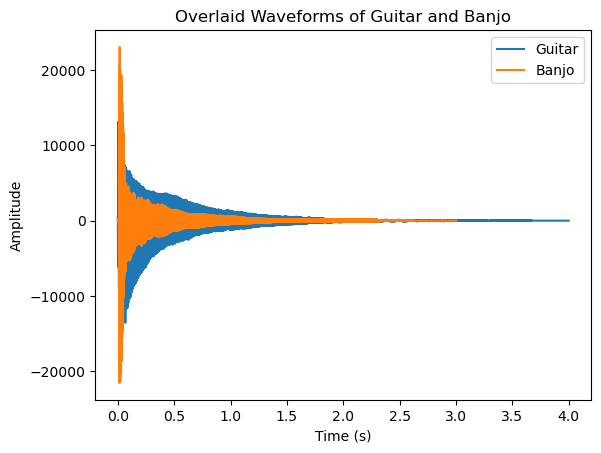

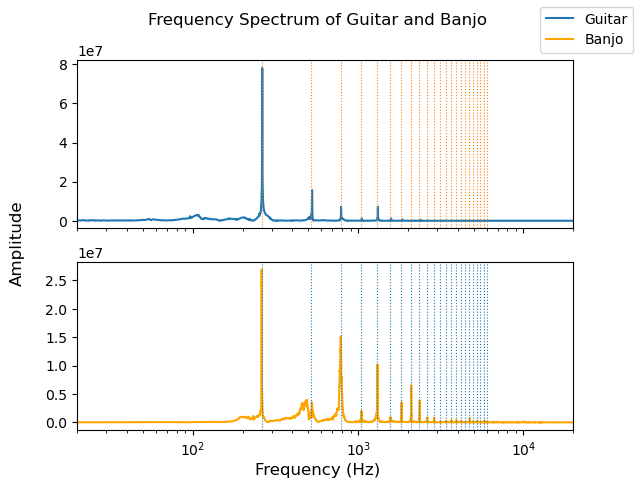

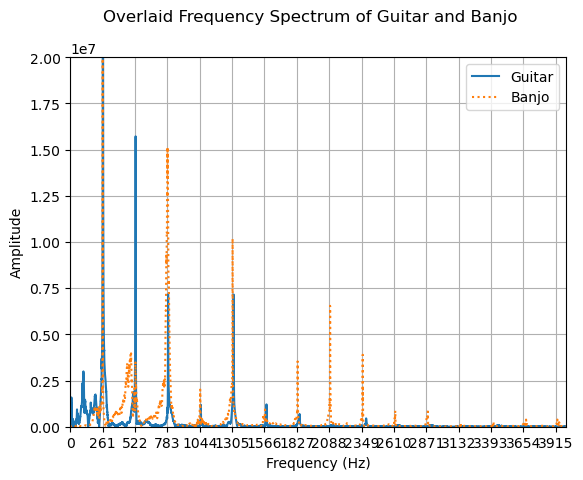

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
from scipy import fft
from IPython.display import Audio

SAMP_RATE, guitar_data = wav.read("data/guitar-mono.wav")
_, banjo_data = wav.read("data/banjo-mono.wav")
guitar_n = guitar_data.size
banjo_n = banjo_data.size

display(Audio(guitar_data, rate=SAMP_RATE))
display(Audio(banjo_data, rate=SAMP_RATE))

plt.plot(np.arange(guitar_n) / SAMP_RATE, guitar_data, label="Guitar")
plt.plot(np.arange(banjo_n) / SAMP_RATE, banjo_data, label="Banjo")
plt.title("Overlaid Waveforms of Guitar and Banjo")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()
plt.close()

dt = 1 / SAMP_RATE
guitar_fft = fft.rfft(guitar_data)
guitar_fftfreq = fft.rfftfreq(guitar_n, dt)
banjo_fft = fft.rfft(banjo_data)
banjo_fftfreq = fft.rfftfreq(banjo_n, dt)

FUND = 261

fig, (ax1, ax2) = plt.subplots(2, sharex=True, constrained_layout=False)
ax1.semilogx(guitar_fftfreq, np.abs(guitar_fft), label="Guitar")
# ax1.set_ylabel("Amplitude")
ax1.set_xlim(20,20000)
for harmonic in range(24):
    ax1.axvline(x=FUND*harmonic, c='C1', ls=':', lw=0.8)

ax2.semilogx(banjo_fftfreq, np.abs(banjo_fft), color='orange', label="Banjo")
# ax2.set_ylabel("Amplitude")
ax2.set_xlim(20,20000)
for harmonic in range(24):
    ax2.axvline(x=FUND*harmonic, c='C0', ls=':', lw=0.8)

fig.suptitle("Frequency Spectrum of Guitar and Banjo")
fig.supxlabel("Frequency (Hz)")
fig.supylabel("Amplitude")
fig.legend()
plt.show()
plt.close()

plt.plot(guitar_fftfreq, np.abs(guitar_fft), label="Guitar")
plt.plot(banjo_fftfreq, np.abs(banjo_fft), ':', label="Banjo")
plt.xlim(20,20000)
plt.suptitle("Overlaid Frequency Spectrum of Guitar and Banjo")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.xlim(20, 4000)
plt.ylim(0, 2e7)
# for harmonic in range(24):
#     plt.axvline(x=FUND*harmonic, c='C4', ls=':', lw=0.5)
plt.xticks(np.arange(0, 4000, FUND))
plt.legend()
plt.grid()
plt.show()
plt.close()

To verify this model answers the question, you can notice differences between intensities of frequency peaks, combinations of different frequency peaks across each instrument, and other differences between the two frequency distributions.

You can even use an inverse FFT to bring a frequency distribution back into its amplitudes, and play the audio out loud:

In [54]:
# 
ifft_amp_g = np.fft.ifft(Xk_g)

# 
Audio(ifft_amp_g, rate=rate_g)

&#x2705; Your group might have different code than above. Bring your computational model from ICA 6.1 into this notebook. 

&#x2705; You are also welcome to use the above code for today's assignment if your group agrees on doing this and takes the time to go through and **explain what each part of the code is doing by filling in the empty comments.**

&#x2705; List the comparisons and differences you can draw between the two frequency distributions.

---

## Part 2: Using a working model

At the end of the modeling cycle we have Step 4: Test the effectiveness of your model using your planned validation process.

This is what you did above in Part 1.

From here, we can return to Step 1: Pose a question of a real-world physics phenomena.

However, we do not have to immediately try to push the boundaries of our model and force ourselves to refine our model further (that would entail continuing on to Step 2 and 3). Instead, we can use our model to see what else it can enable us to investigate. There are many questions we could answer without needing to reinitiate the modeling cycle.

You now have the tools you need to translate back from a frequency distribution to an audio sample. You can even test out some of the comparisons you made at the end of Part 1. For example, *does the banjo twang really come from those high-frequency peaks?*

&#x2705; Today, use your model of the frequency distributions to investigate new questions. You can edit the existing frequencies however you like, and test your changes through plotting, listening to the resulting audio, or any other method your group comes up with.